# 01 — Mega Table Overview

Phase 2 EDA starting point. Goals:
- Row counts and null rates by position
- ADP vs finish correlations
- Feature distributions and outliers
- Prioritize features for Bucket A/B engineering

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../../data")

qb = pd.read_csv(DATA_DIR / "training_data_qb.csv")
rb = pd.read_csv(DATA_DIR / "training_data_rb.csv")
wr = pd.read_csv(DATA_DIR / "training_data_wr.csv")
te = pd.read_csv(DATA_DIR / "training_data_te.csv")

tables = {"QB": qb, "RB": rb, "WR": wr, "TE": te}

for pos, df in tables.items():
    # Fill undrafted players with end-of-draft proxy so ADP is never null.
    df["adp_overall"]       = df["adp_overall"].fillna(300.0)
    df["adp_position_rank"] = df["adp_position_rank"].fillna(75.0)

    # Career season number — rank each player's appearances chronologically.
    df["career_season"] = (
        df.groupby("full_name")["season"]
        .rank(method="first")
        .astype(int)
    )

    # PPG and deltas (computed here for existing CSVs; baked into future builds).
    df["ppg"]       = df["fantasy_points_ppr"] / df["games_played"].replace(0, float("nan"))
    df["prev_ppg"]  = df["prev_fantasy_points_ppr"] / df["prev_games_played"].replace(0, float("nan"))
    df["ppg_delta"] = df["ppg"] - df["prev_ppg"]
    df["pts_delta"] = df["fantasy_points_ppr"] - df["prev_fantasy_points_ppr"]

for pos, df in tables.items():
    print(f"{pos}: {df.shape[0]} rows × {df.shape[1]} cols  |  seasons {df['season'].min()}–{df['season'].max()}")

QB: 385 rows × 35 cols  |  seasons 2016–2025
RB: 894 rows × 47 cols  |  seasons 2016–2025
WR: 1020 rows × 35 cols  |  seasons 2016–2025
TE: 349 rows × 35 cols  |  seasons 2016–2025


## Player profile — all seasons for one player

In [68]:
def player_profile(name: str, pos: str) -> pd.DataFrame:
    df = tables[pos]
    match = df[df["full_name"].str.contains(name, case=False, na=False)].copy()
    cols = [
        "full_name", "season", "career_season", "team",
        "adp_overall", "adp_position_rank", "finish",
        "fantasy_points_ppr", "games_played", "ppg",
        "prev_fantasy_points_ppr", "prev_ppg",
        "pts_delta", "ppg_delta",
    ]
    present = [c for c in cols if c in match.columns]
    return match[present].reset_index(drop=True)

player_profile("Tyreek Hill", "WR")

,full_name,season,career_season,team,adp_overall,adp_position_rank,finish,fantasy_points_ppr,games_played,ppg,prev_fantasy_points_ppr,prev_ppg,pts_delta,ppg_delta
0,Tyreek Hill,2016,1,KC,300.0,75.0,18,219.0,16,13.687500,NaN,NaN,NaN,NaN
1,Tyreek Hill,2017,2,KC,45.5,22.0,8,245.2,15,16.346667,219.0,13.687500,26.2,2.659167
2,Tyreek Hill,2018,3,KC,23.7,9.0,1,334.0,16,20.875000,245.2,16.346667,88.8,4.528333
3,Tyreek Hill,2019,4,KC,13.9,6.0,32,188.3,12,15.691667,334.0,20.875000,-145.7,-5.183333
4,Tyreek Hill,2020,5,KC,15.8,4.0,2,328.9,15,21.926667,188.3,15.691667,140.6,6.235000
5,Tyreek Hill,2021,6,KC,10.6,2.0,6,296.5,17,17.441176,328.9,21.926667,-32.4,-4.485490
6,Tyreek Hill,2022,7,MIA,22.7,8.0,2,341.2,17,20.070588,296.5,17.441176,44.7,2.629412
7,Tyreek Hill,2023,8,MIA,4.4,3.0,2,376.4,16,23.525000,341.2,20.070588,35.2,3.454412
8,Tyreek Hill,2024,9,MIA,2.6,1.0,18,218.2,17,12.835294,376.4,23.525000,-158.2,-10.689706
9,Tyreek Hill,2025,10,MIA,26.9,14.0,72,53.5,4,13.375000,218.2,12.835294,-164.7,0.539706


In [69]:
# Full feature row for a single player-season — useful for inspecting what the model sees
def feature_row(name: str, pos: str, season: int) -> pd.Series:
    df = tables[pos]
    row = df[(df["full_name"].str.contains(name, case=False, na=False)) & (df["season"] == season)]
    return row.T.rename(columns={row.index[0]: f"{name} {season}"})

feature_row("Tyreek Hill", "WR", 2022)

,Tyreek Hill 2022
full_name,Tyreek Hill
season,2022
team,MIA
adp_overall,22.7
adp_position_rank,8.0
finish,2
games_played,17
fantasy_points_ppr,341.2
receptions,119
receiving_yards,1710


## Null rates by column

In [70]:
def null_rates(pos: str) -> pd.DataFrame:
    df = tables[pos]
    pct = (df.isnull().mean() * 100).round(1)
    return pct[pct > 0].rename(f"null% ({pos})").to_frame().sort_values(f"null% ({pos})", ascending=False)

null_rates("WR")

,null% (WR)
prev_yac_per_reception,15.2
prev_receiving_tds,14.8
prev_target_share,14.8
ppg_delta,14.8
prev_ppg,14.8
prev_rz_target_share,14.8
prev_air_yards_share,14.8
prev_catch_rate,14.8
prev_adot,14.8
prev_rz_targets,14.8


## ADP vs finish — does the market get it right?

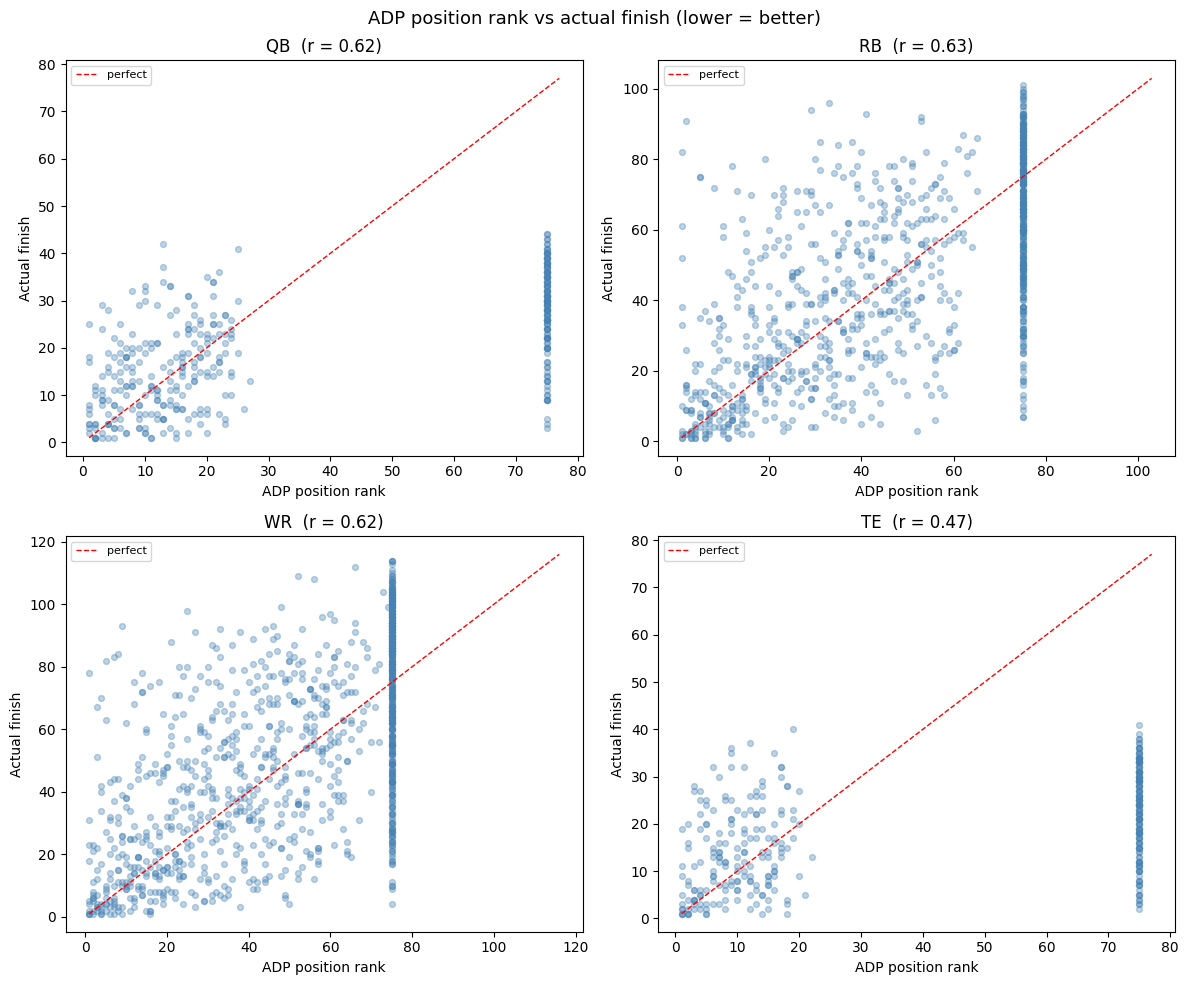

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("ADP position rank vs actual finish (lower = better)", fontsize=13)

for ax, (pos, df) in zip(axes.flat, tables.items()):
    sub = df.dropna(subset=["adp_position_rank", "finish"])
    ax.scatter(sub["adp_position_rank"], sub["finish"], alpha=0.35, s=18, color="steelblue")
    # 45-degree line = perfect prediction
    lim = max(sub["adp_position_rank"].max(), sub["finish"].max()) + 2
    ax.plot([1, lim], [1, lim], "r--", linewidth=1, label="perfect")
    corr = sub["adp_position_rank"].corr(sub["finish"])
    ax.set_title(f"{pos}  (r = {corr:.2f})")
    ax.set_xlabel("ADP position rank")
    ax.set_ylabel("Actual finish")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Correlation of prior-season features with current finish (WR)

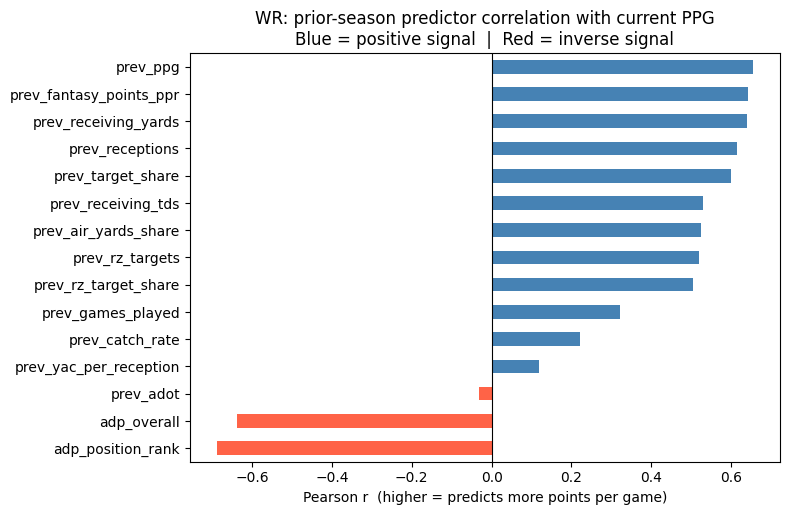

In [72]:
def feature_corr_with_ppg(pos: str) -> None:
    """
    Correlate prior-season predictors with current-season PPG.
    Positive bar = predictor goes up when PPG goes up (good signal).
    Negative bar = predictor goes up when PPG goes down (inverse signal).
    """
    df = tables[pos].copy()
    pred_cols = [c for c in df.columns if c.startswith("prev_") or c in ("adp_overall", "adp_position_rank")]
    sub = df[pred_cols + ["ppg"]].dropna(subset=["ppg"])
    corr = (
        sub.corr(numeric_only=True)["ppg"]
        .drop("ppg")
        .dropna()
        .sort_values()
    )

    colors = ["steelblue" if v > 0 else "tomato" for v in corr]
    fig, ax = plt.subplots(figsize=(8, max(4, len(corr) * 0.35)))
    corr.plot(kind="barh", ax=ax, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{pos}: prior-season predictor correlation with current PPG\n"
                 "Blue = positive signal  |  Red = inverse signal")
    ax.set_xlabel("Pearson r  (higher = predicts more points per game)")
    plt.tight_layout()
    plt.show()

feature_corr_with_ppg("WR")

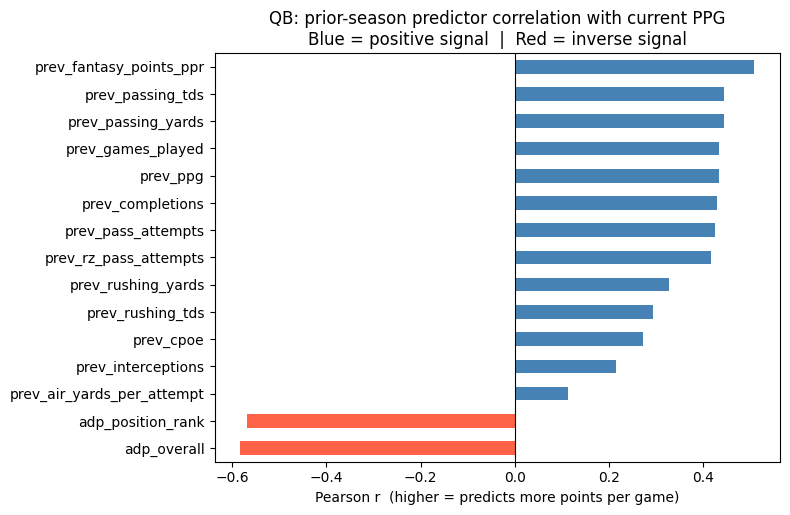

In [73]:
feature_corr_with_ppg("QB")

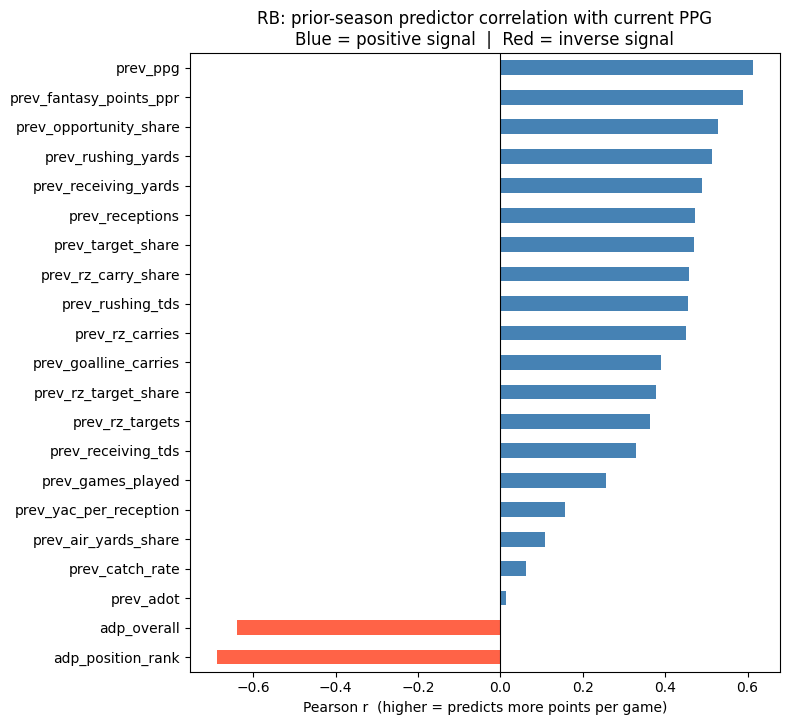

In [74]:
feature_corr_with_ppg("RB")

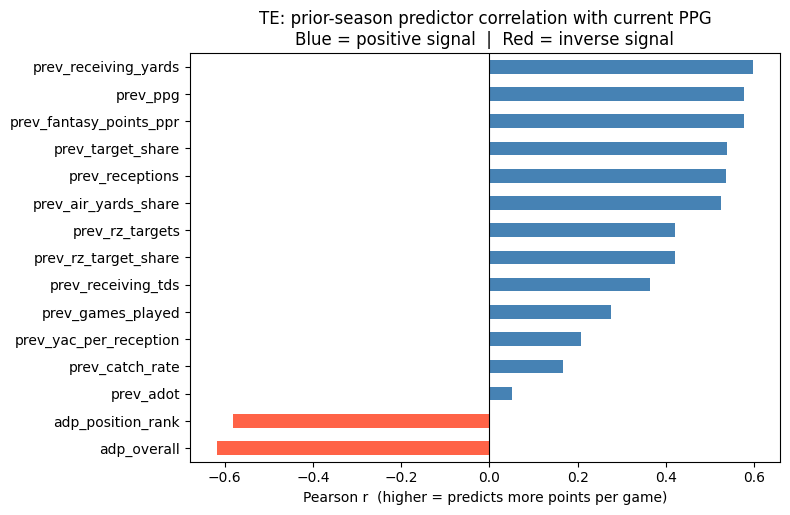

In [75]:
feature_corr_with_ppg("TE")

## ADP value — biggest over/underperformers vs ADP

In [76]:
def adp_value(pos: str, n: int = 10) -> None:
    df = tables[pos].copy()
    df["value"] = df["adp_position_rank"] - df["finish"]
    cols = ["full_name", "season", "career_season", "adp_position_rank", "finish", "ppg", "value"]
    present = [c for c in cols if c in df.columns]

    steals = df.nlargest(n, "value")[present].reset_index(drop=True)
    busts  = df.nsmallest(n, "value")[present].reset_index(drop=True)

    pad = "=" * 64
    print(f"\n{pad}")
    print(f"  {pos} — Biggest STEALS  (finished much higher than ADP)")
    print(f"{pad}")
    print(steals.to_string(index=False))

    print(f"\n{pad}")
    print(f"  {pos} — Biggest BUSTS   (finished much lower than ADP)")
    print(f"{pad}")
    print(busts.to_string(index=False))

adp_value("WR")


  WR — Biggest STEALS  (finished much higher than ADP)
      full_name  season  career_season  adp_position_rank  finish       ppg  value
     Puka Nacua    2023              1               75.0       4 17.558824   71.0
  Davante Adams    2016              1               75.0       9 15.418750   66.0
 Hunter Renfrow    2021              3               75.0      10 15.241176   65.0
 Michael Wilson    2025              3               75.0      10 12.976471   65.0
 DeVante Parker    2019              4               75.0      11 15.387500   64.0
     Tyler Boyd    2018              3               75.0      17 15.792857   58.0
     D.J. Chark    2019              2               75.0      17 15.053333   58.0
    Tyreek Hill    2016              1               75.0      18 13.687500   57.0
Michael Pittman    2025              6               75.0      18 11.905882   57.0
Tyrell Williams    2016              1               75.0      19 13.556250   56.0

  WR — Biggest BUSTS   (finish

In [77]:
adp_value("QB")


  QB — Biggest STEALS  (finished much higher than ADP)
       full_name  season  career_season  adp_position_rank  finish       ppg  value
Matthew Stafford    2025             10               75.0       3 20.610588   72.0
      Alex Smith    2017              2               75.0       4 19.678667   71.0
      Geno Smith    2022              6               75.0       5 17.875294   70.0
  Justin Herbert    2020              1               75.0       9 22.189333   66.0
    Daniel Jones    2022              4               75.0       9 18.062500   66.0
     C.J. Stroud    2023              1               75.0       9 18.334667   66.0
     Sam Darnold    2024              7               75.0       9 18.115294   66.0
      Jared Goff    2022              7               75.0      10 16.724706   65.0
  Baker Mayfield    2023              6               75.0      10 16.121176   65.0
    Kirk Cousins    2020              5               75.0      11 19.137500   64.0

  QB — Biggest BUST

In [78]:
adp_value("RB")


  RB — Biggest STEALS  (finished much higher than ADP)
            full_name  season  career_season  adp_position_rank  finish       ppg  value
       James Robinson    2020              1               75.0       7 17.885714   68.0
       Kyren Williams    2023              2               75.0       7 21.250000   68.0
Cordarrelle Patterson    2021              1               75.0       9 14.662500   66.0
        Jordan Howard    2016              1               75.0      10 15.340000   65.0
           Mike Davis    2020              5               75.0      12 14.750000   63.0
      Phillip Lindsay    2018              1               75.0      13 14.853333   62.0
     Kenneth Gainwell    2025              5               75.0      16 13.017647   59.0
      Jerick McKinnon    2017              2               75.0      17 11.131250   58.0
        J.D. McKissic    2020              5               75.0      17 11.962500   58.0
          Rico Dowdle    2025              4          

In [79]:
adp_value("TE")


  TE — Biggest STEALS  (finished much higher than ADP)
     full_name  season  career_season  adp_position_rank  finish       ppg  value
  Kyle Rudolph    2016              1               75.0       2 13.062500   73.0
  Logan Thomas    2020              4               75.0       3 11.038750   72.0
Dalton Schultz    2021              4               75.0       3 12.282353   72.0
 Robert Tonyan    2020              3               75.0       4 11.773333   71.0
   Jonnu Smith    2024              8               75.0       4 13.076471   71.0
   Evan Engram    2017              1               75.0       5 11.573333   70.0
    Jared Cook    2018              3               75.0       5 12.100000   70.0
   Evan Engram    2022              6               75.0       5 10.405882   70.0
  Tyler Higbee    2022              7               75.0       6  9.500000   69.0
  Trey McBride    2023              2               75.0       7 10.676471   68.0

  TE — Biggest BUSTS   (finished much low